In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd


import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)


/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
caminho_csv = "alertas_inmet.csv"
df = pd.read_csv(caminho_csv)

df_onda_calor = df.query("evento == 'Onda de Calor'")
df_onda_calor['data_envio'] = pd.to_datetime(df_onda_calor['data_envio'])
df_onda_calor['ano'] = df_onda_calor['data_envio'].dt.year
df_onda_calor['mes'] = df_onda_calor['data_envio'].dt.month

### Análise por aviso emitido

In [ ]:
avisos_por_ano = df_onda_calor.groupby('ano').size().reset_index(name='qtd_avisos')
print(avisos_por_ano)

    ano  qtd_avisos
0  2021          10
1  2022          15
2  2023          60
3  2024          96
4  2025          27


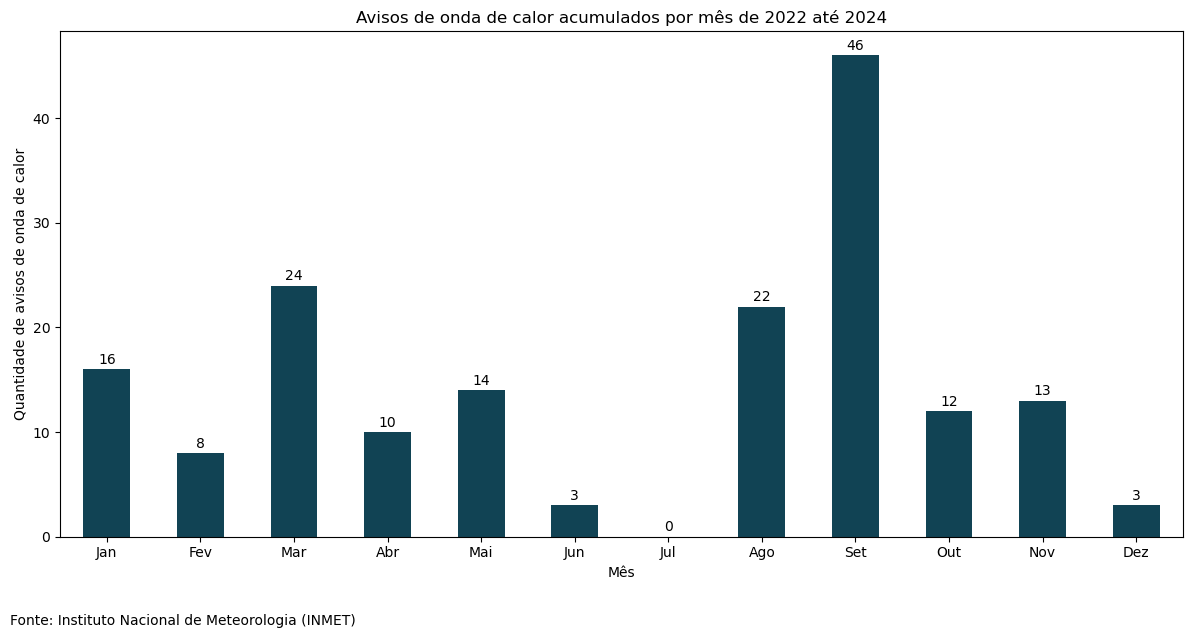

In [3]:
nomes_meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
               'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

plt.figure(figsize=(12, 6))

seq_blue = ["#114354"]
cores = seq_blue * (12 // len(seq_blue)) + seq_blue[:12 % len(seq_blue)]

df_explodido_plot = df_onda_calor.query("ano>=2022 and ano <=2024")
avisos_por_mes = df_explodido_plot['mes'].value_counts().sort_index()
avisos_por_mes = avisos_por_mes.reindex(range(1, 13), fill_value=0)

barras = avisos_por_mes.plot(kind='bar', color=cores)

for i, valor in enumerate(avisos_por_mes):
    texto_formatado = format(valor, ',').replace(',', '.')
    plt.text(i, valor + 0.005 * max(avisos_por_mes), texto_formatado, 
             ha='center', va='bottom')

plt.xlabel('Mês')
plt.ylabel('Quantidade de avisos de onda de calor')
plt.title('Avisos de onda de calor acumulados por mês de 2022 até 2024')
plt.xticks(ticks=range(12), labels=nomes_meses, rotation=0)
plt.figtext(0.01, -0.05, 'Fonte: Instituto Nacional de Meteorologia (INMET)', ha='left', fontsize=10)

plt.tight_layout()
plt.show()


### Análise por município com aviso

In [4]:
df_onda_calor['municipios'] = df_onda_calor['municipios'].str.split(',')
df_explodido = df_onda_calor.explode('municipios')
df_explodido['municipios'] = df_explodido['municipios'].str.strip()

pattern = r'^(.*?)\s*-\s*([A-Z]{2})\s*\((\d+)\)$'
df_explodido[['nome_municipio', 'uf', 'codigo_ibge_municipio']] = df_explodido['municipios'].str.extract(pattern)
df_explodido = df_explodido[['data_envio', 'evento', 'severidade', 'descricao', 'instrucoes', 'nome_municipio', 'uf', 'codigo_ibge_municipio']]

df_explodido['data_envio'] = pd.to_datetime(df_explodido['data_envio'])
df_explodido['ano'] = df_explodido['data_envio'].dt.year
df_explodido['mes'] = df_explodido['data_envio'].dt.month

In [9]:
df_explodido.to_csv("../../dados_ondas_calor.csv")

In [5]:
quantidade_eventos_por_municipio = df_explodido.groupby('codigo_ibge_municipio').size().reset_index(name='quantidade_eventos')
quantidade_eventos_por_municipio["codigo_ibge_municipio"] = quantidade_eventos_por_municipio["codigo_ibge_municipio"].astype(int)
quantidade_eventos_por_municipio

,codigo_ibge_municipio,quantidade_eventos
0,1100015,30
1,1100023,26
2,1100031,33
3,1100049,30
4,1100056,33
...,...,...
4470,5222005,31
4471,5222054,46
4472,5222203,21
4473,5222302,32


In [6]:
gdf = gpd.read_file("../ibge_malha_municipal/BR_Municipios_2024.shp")
gdf["codigo_ibge_municipio"] = gdf["CD_MUN"].astype(int)

In [7]:
merged = gdf.merge(quantidade_eventos_por_municipio, on=["codigo_ibge_municipio"], how="left")
merged = merged[['geometry', 'codigo_ibge_municipio', 'SIGLA_UF', 'quantidade_eventos']]
merged['quantidade_eventos'] = merged['quantidade_eventos'].fillna(0)


/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_84922/330810905.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  borda_uf['centroide'] = borda_uf.geometry.centroid


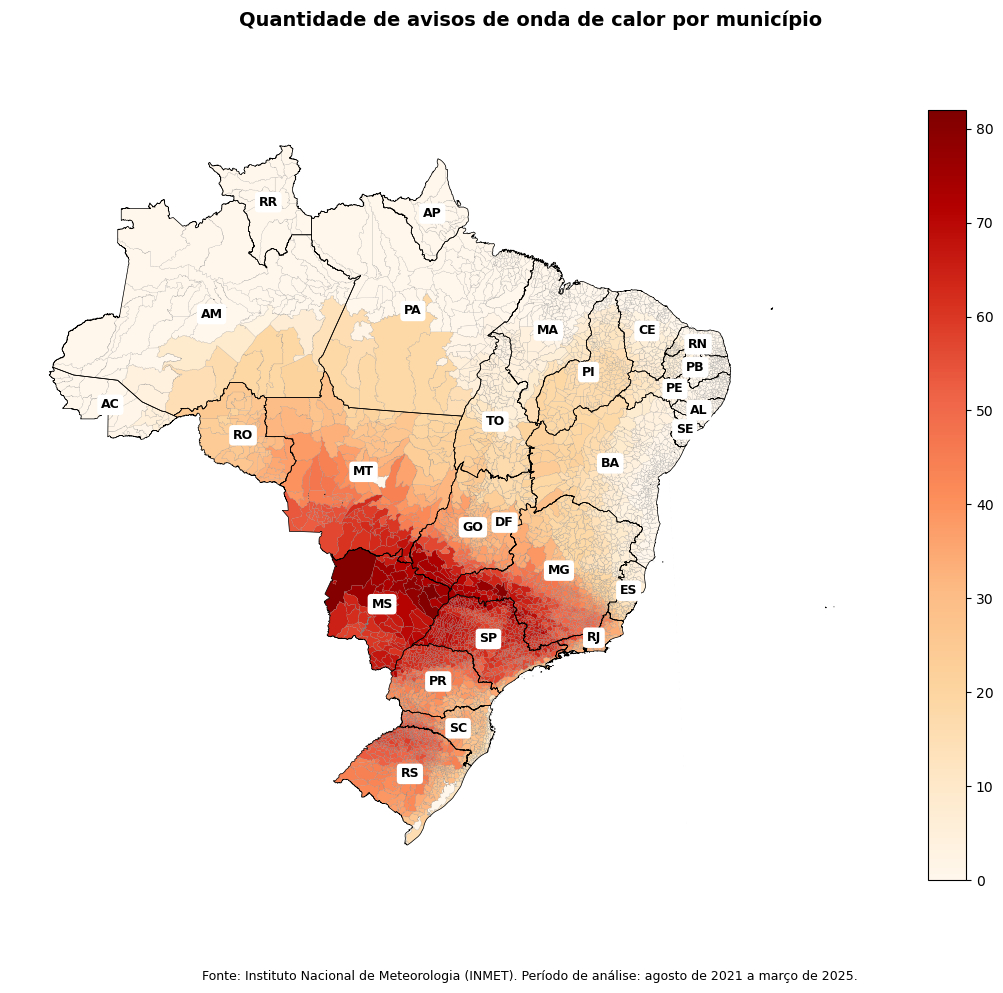

In [8]:
borda_uf = merged.dissolve(by='SIGLA_UF')
borda_uf['SIGLA_UF'] = borda_uf.index  

borda_uf['centroide'] = borda_uf.geometry.centroid

fig, ax = plt.subplots(figsize=(14, 10))
merged.plot(column='quantidade_eventos',
                     cmap='OrRd',
                     linewidth=0.1,
                     edgecolor='gray',
                     legend=True,
                     ax=ax)

borda_uf.boundary.plot(ax=ax, color='black', linewidth=0.5)

for _, row in borda_uf.iterrows():
    x = row['centroide'].x
    y = row['centroide'].y
    sigla = row['SIGLA_UF']
    ax.text(x, y, sigla,
            fontsize=9, fontweight='bold', ha='center', va='center',
            color='black',
            bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))

plt.suptitle('Quantidade de avisos de onda de calor por município', fontsize=14, fontweight='bold')
plt.figtext(0.5, 0.01,
            'Fonte: Instituto Nacional de Meteorologia (INMET). Período de análise: agosto de 2021 a março de 2025.',
            wrap=True, horizontalalignment='center', fontsize=9)
plt.axis('off')
plt.show()